# Ejercicio 1.

#### Encuentre todos los puntos críticos de la siguiente función y clasifíquelos como máximo local, mínimo local o punto de silla, utilizando el método gráfico y las condiciones de optimalidad de primer y segundo orden.

$$f(x,y) = x^3 + y^3 - 3xy$$

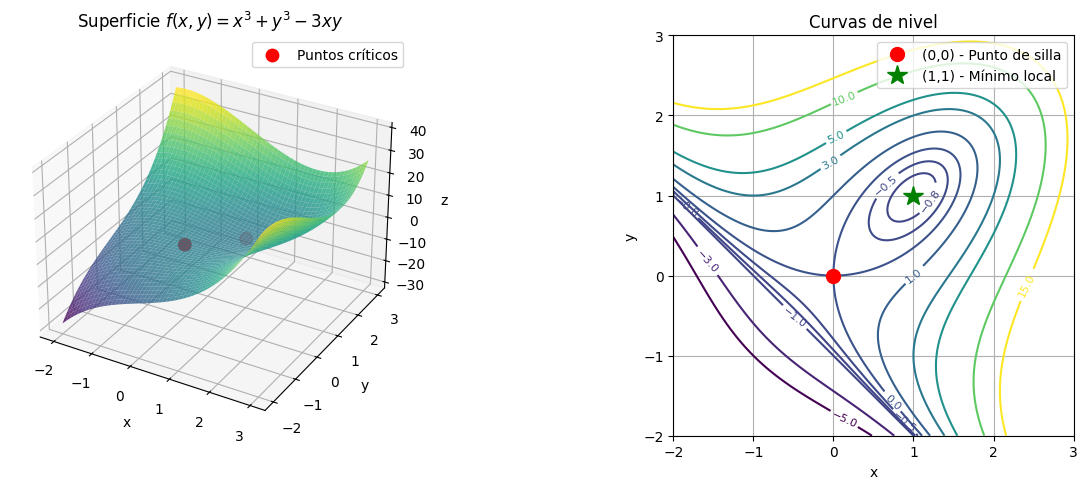

In [12]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x, y: x**3 + y**3 - 3*x*y

x = np.linspace(-2, 3, 200)
y = np.linspace(-2, 3, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Gráfico 3D
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.scatter([0, 1], [0, 1], [f(0,0), f(1,1)], color='red', s=80, zorder=5, label='Puntos críticos')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Superficie $f(x,y) = x^3 + y^3 - 3xy$')
ax1.legend()

# Curvas de nivel
ax2 = fig.add_subplot(122)
contours = ax2.contour(X, Y, Z, levels=[-5, -3, -1, -0.8, -0.5, 0, 1, 3, 5, 10, 15], cmap='viridis')
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(0, 0, 'ro', markersize=10, label='(0,0) - Punto de silla')
ax2.plot(1, 1, 'g*', markersize=15, label='(1,1) - Mínimo local')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel')
ax2.grid(True)
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## Desarrollo.

#### Condición de optimalidad de primer orden (gradiente = 0):

$$\frac{\partial f}{\partial x} = 3x^2 - 3y = 0 \quad \Rightarrow \quad y = x^2$$

$$\frac{\partial f}{\partial y} = 3y^2 - 3x = 0 \quad \Rightarrow \quad x = y^2$$

Sustituyendo $y = x^2$ en $x = y^2$:

$$x = (x^2)^2 = x^4 \quad \Rightarrow \quad x^4 - x = 0 \quad \Rightarrow \quad x(x^3 - 1) = 0$$

**Puntos críticos:** $(0, 0)$ y $(1, 1)$

---

#### Condición de optimalidad de segundo orden (Hessiano):

La matriz Hessiana de $f$ es:

$$H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix} = \begin{bmatrix} 6x & -3 \\ -3 & 6y \end{bmatrix}$$

**En $(0, 0)$:**

$$H(0,0) = \begin{bmatrix} 0 & -3 \\ -3 & 0 \end{bmatrix}, \quad \det(H) = 0 - 9 = -9 < 0 \quad \Rightarrow \quad \textbf{Punto de silla}$$

**En $(1, 1)$:**

$$H(1,1) = \begin{bmatrix} 6 & -3 \\ -3 & 6 \end{bmatrix}, \quad \det(H) = 36 - 9 = 27 > 0, \quad H_{11} = 6 > 0 \quad \Rightarrow \quad \textbf{Mínimo local}$$

$$f(1,1) = 1 + 1 - 3 = -1$$

In [13]:
from scipy.optimize import minimize
import numpy as np

def funcion_objetivo(x):
    return x[0]**3 + x[1]**3 - 3*x[0]*x[1]

# Buscar mínimo local partiendo cerca de (1,1)
x0 = np.array([0.5, 0.5])
result = minimize(funcion_objetivo, x0, method='Nelder-Mead')
print("Mínimo local encontrado:")
print(result)
print(f"\nPunto: ({result.x[0]:.4f}, {result.x[1]:.4f})")
print(f"Valor: {result.fun:.4f}")

Mínimo local encontrado:
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.9999999956378387
             x: [ 1.000e+00  1.000e+00]
           nit: 34
          nfev: 62
 final_simplex: (array([[ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00]]), array([-1.000e+00, -1.000e+00, -1.000e+00]))

Punto: (1.0000, 1.0000)
Valor: -1.0000


# Ejercicio 2

#### Se le entrega el siguiente problema de optimización con restricción de igualdad. Resuelva mediante multiplicadores de Lagrange.

### Objetivo:

$$
\min f(x, y) = x^2 + 2y^2 + xy
$$

### Sujeto a:

$$x + y = 12$$
$$x \geq 0$$
$$y \geq 0$$

Para un mejor entendimiento:

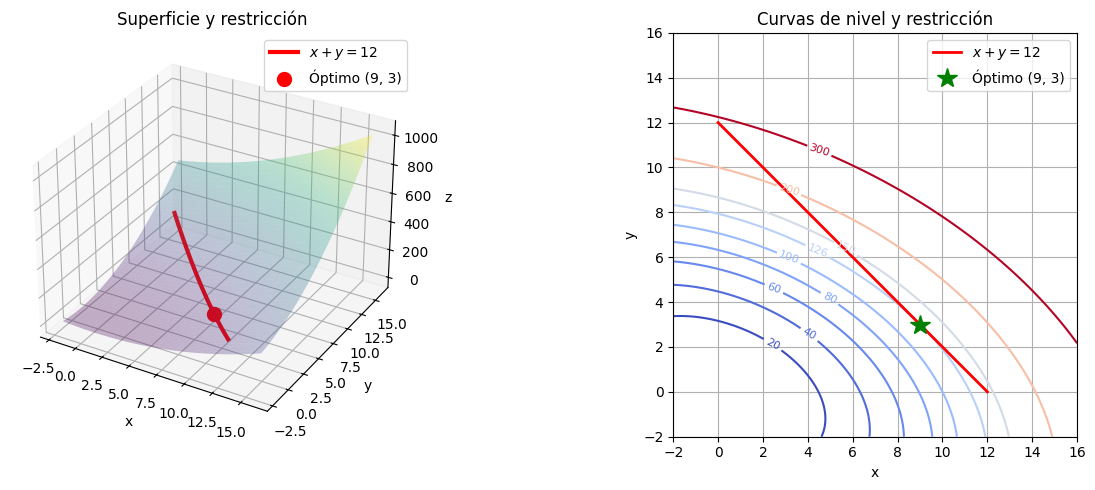

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Función objetivo
def fobj(x, y):
    return x**2 + 2*y**2 + x*y

# Restricción: x + y = 12
def g(x, y):
    return x + y - 12

x = np.linspace(-2, 16, 200)
y = np.linspace(-2, 16, 200)
X, Y = np.meshgrid(x, y)
Z = fobj(X, Y)

fig = plt.figure(figsize=(14, 5))

# Gráfico 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none')
# Dibujar la restricción como una curva sobre la superficie
x_rest = np.linspace(0, 12, 100)
y_rest = 12 - x_rest
z_rest = fobj(x_rest, y_rest)
ax1.plot(x_rest, y_rest, z_rest, 'r-', linewidth=3, label='$x + y = 12$')
ax1.scatter([9], [3], [fobj(9, 3)], color='red', s=100, zorder=5, label=f'Óptimo (9, 3)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Superficie y restricción')
ax1.legend()

# Curvas de nivel con restricción
ax2 = fig.add_subplot(122)
contours = ax2.contour(X, Y, Z, levels=[20, 40, 60, 80, 100, 126, 150, 200, 300], cmap='coolwarm')
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_rest, y_rest, 'r-', linewidth=2, label='$x + y = 12$')
ax2.plot(9, 3, 'g*', markersize=15, label='Óptimo (9, 3)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel y restricción')
ax2.set_xlim(-2, 16)
ax2.set_ylim(-2, 16)
ax2.grid(True)
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## Desarrollo.

#### Primero, construimos el Lagrangiano:

$$L(x, y, \lambda) = f(x, y) + \lambda \cdot g(x, y)$$
$$L(x, y, \lambda) = x^2 + 2y^2 + xy + \lambda (x + y - 12)$$

#### Derivadas parciales:
1. $$\frac{\partial L}{\partial x} = 2x + y + \lambda = 0$$
2. $$\frac{\partial L}{\partial y} = 4y + x + \lambda = 0$$
3. $$\frac{\partial L}{\partial \lambda} = x + y - 12 = 0$$

#### Resolución:

De las ecuaciones (1) y (2), igualando $\lambda$:
$$-(2x + y) = -(4y + x) \quad \Rightarrow \quad 2x + y = 4y + x \quad \Rightarrow \quad x = 3y$$

Reemplazando en la restricción (3):
$$3y + y = 12 \quad \Rightarrow \quad y^* = 3, \quad x^* = 9$$

$$\lambda^* = -(2(9) + 3) = -21$$

#### Valor óptimo:
$$f(9, 3) = 81 + 18 + 27 = 126$$

#### Verificación de que es un mínimo:

La Hessiana de $f$ es:
$$H_f = \begin{bmatrix} 2 & 1 \\ 1 & 4 \end{bmatrix}$$

$\det(H_f) = 8 - 1 = 7 > 0$ y $H_{11} = 2 > 0$, por lo tanto $f$ es estrictamente convexa. Esto garantiza que el punto encontrado es un **mínimo global** sobre la restricción.

Además, verificamos en las fronteras ($x=0$ o $y=0$):
- Si $x = 0$: $y = 12$, $f(0, 12) = 288$
- Si $y = 0$: $x = 12$, $f(12, 0) = 144$

Ambos valores son mayores que $126$, confirmando el mínimo.

In [15]:
from scipy.optimize import minimize
import numpy as np

fo = lambda x: x[0]**2 + 2*x[1]**2 + x[0]*x[1]
restriccion = lambda x: x[0] + x[1] - 12

x0 = np.array([6, 6])
constraints = [{'type': 'eq', 'fun': restriccion}]

noneg = [(0, np.inf), (0, np.inf)]

res = minimize(fo, x0, constraints=constraints, bounds=noneg)
print(f"\nPunto óptimo: x = {res.x[0]:.4f}, y = {res.x[1]:.4f}")
print(f"Valor óptimo: {res.fun:.4f}")


Punto óptimo: x = 9.0000, y = 3.0000
Valor óptimo: 126.0000


# Ejercicio 3.
#### Resuelva la misma función del ejercicio 2, con Gurobi.

In [16]:
import gurobipy as gp
from gurobipy import GRB

# Crear modelo
model = gp.Model("Ejercicio 3")

# Variables de decisión
x = model.addVar(name="x", lb=0, vtype=GRB.CONTINUOUS)
y = model.addVar(name="y", lb=0, vtype=GRB.CONTINUOUS)

# Función objetivo: min x^2 + 2y^2 + xy
model.setObjective(x**2 + 2*y**2 + x*y, GRB.MINIMIZE)

# Restricción de igualdad
model.addConstr(x + y == 12)

# Optimizar modelo
model.optimize()

# Imprimir resultados
if model.status == GRB.OPTIMAL:
    print(f"Optimal solution: x = {x.X}, y = {y.X}")
    print(f"Objective value: {model.objVal}")
else:
    print("No optimal solution found.")

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1 rows, 2 columns and 2 nonzeros
Model fingerprint: 0x39f224de
Model has 3 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 4e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 1e+01]
Presolve time: 0.01s
Presolved: 1 rows, 2 columns, 2 nonzeros
Presolved model has 3 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 1
 AA' NZ     : 1.000e+00
 Factor NZ  : 3.000e+00
 Factor Ops : 5.000e+00 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0 

# Ejercicio 4.

#### Se le entrega el siguiente problema de optimización con restricciones de desigualdad. Resuelva mediante el método de KKT.

### Objetivo:

$$
\min f(x, y) = (x - 3)^2 + (y - 2)^2
$$

### Sujeto a:

\begin{cases}
g_1(x, y) = x^2 + y^2 - 5 \leq 0\\
g_2(x, y) = x + 2y - 4 \leq 0\\
g_3(x) = x \geq 0\\
g_4(y) = y \geq 0
\end{cases}

Para un mejor entendimiento:

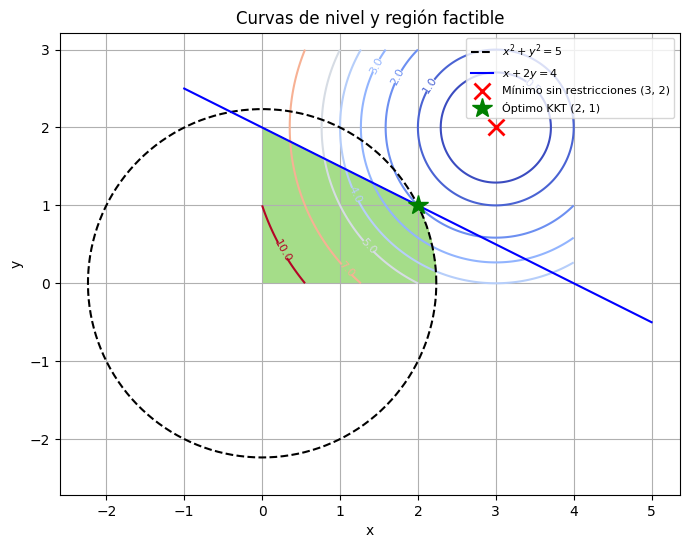

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Crear malla
x = np.linspace(0, 4, 400)
y = np.linspace(0, 3, 400)
X, Y = np.meshgrid(x, y)

# Función objetivo
Z = (X - 3)**2 + (Y - 2)**2

# Restricciones
g1 = X**2 + Y**2 <= 5
g2 = X + 2*Y <= 4
g3 = (X >= 0) & (Y >= 0)
factible = g1 & g2 & g3

# Crear figura
plt.figure(figsize=(8, 6))

# Dibujar curvas de nivel
contours = plt.contour(X, Y, Z, levels=[0.5, 1, 2, 3, 4, 5, 7, 10], cmap='coolwarm')
plt.clabel(contours, inline=True, fontsize=8)

# Sombrear región factible
plt.contourf(X, Y, factible.astype(float), levels=[0.5, 1], colors=["#4dbc15"], alpha=0.5)

# Dibujar fronteras
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.sqrt(5)*np.cos(theta), np.sqrt(5)*np.sin(theta), 'k--', label='$x^2 + y^2 = 5$')
x_line = np.linspace(-1, 5, 100)
plt.plot(x_line, (4 - x_line)/2, 'b-', label='$x + 2y = 4$')

# Marcar mínimo sin restricciones y óptimo restringido
plt.plot(3, 2, 'rx', markersize=12, markeredgewidth=2, label='Mínimo sin restricciones (3, 2)')
plt.plot(2, 1, 'g*', markersize=15, label='Óptimo KKT (2, 1)')

# Configurar gráfica
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curvas de nivel y región factible')
plt.xlim(0, 4)
plt.ylim(0, 3)
plt.grid(True)
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')

plt.show()

## Desarrollo.

#### Primero, construimos el Lagrangiano:

$$L(x, y, \lambda_i) = (x-3)^2 + (y-2)^2 + \lambda_1 (x^2 + y^2 - 5) + \lambda_2 (x + 2y - 4) - \lambda_3 x - \lambda_4 y$$

#### Derivadas parciales:
1. $$\frac{\partial L}{\partial x} = 2(x-3) + 2\lambda_1 x + \lambda_2 - \lambda_3 = 0$$
2. $$\frac{\partial L}{\partial y} = 2(y-2) + 2\lambda_1 y + 2\lambda_2 - \lambda_4 = 0$$

#### Condiciones de KKT completas:
1. $2(x-3) + 2\lambda_1 x + \lambda_2 - \lambda_3 = 0$
2. $2(y-2) + 2\lambda_1 y + 2\lambda_2 - \lambda_4 = 0$
3. $\lambda_i \geq 0, \quad \forall i$
4. **Holgura complementaria:**
   - $\lambda_1 (x^2 + y^2 - 5) = 0$
   - $\lambda_2 (x + 2y - 4) = 0$
   - $\lambda_3 \cdot (-x) = 0$  (es decir, $\lambda_3 x = 0$)
   - $\lambda_4 \cdot (-y) = 0$  (es decir, $\lambda_4 y = 0$)

---

#### Análisis de casos:

Notamos que el mínimo sin restricciones $(3, 2)$ **no es factible** pues $3^2 + 2^2 = 13 > 5$ y $3 + 2(2) = 7 > 4$. Entonces el óptimo estará en la frontera de alguna restricción activa.

**Supongamos $g_1$ inactiva** ($\lambda_1 = 0$), **$g_2$ activa** ($x + 2y = 4$), y $x > 0$, $y > 0$ ($\lambda_3 = \lambda_4 = 0$):

De (1): $2(x-3) + \lambda_2 = 0 \Rightarrow \lambda_2 = 6 - 2x$

De (2): $2(y-2) + 2\lambda_2 = 0 \Rightarrow y - 2 + \lambda_2 = 0 \Rightarrow \lambda_2 = 2 - y$

Igualando: $6 - 2x = 2 - y \Rightarrow y = 2x - 4$

Combinando con la restricción activa $x + 2y = 4$:
$$x + 2(2x - 4) = 4 \Rightarrow 5x - 8 = 4 \Rightarrow x^* = \frac{12}{5} = 2.4$$
$$y^* = 2(2.4) - 4 = 0.8$$

Verificamos: $\lambda_2 = 6 - 2(2.4) = 1.2 > 0$ ✓

Verificamos $g_1$: $2.4^2 + 0.8^2 = 5.76 + 0.64 = 6.4 > 5$ ❌ **No factible para $g_1$**.

---

**Supongamos $g_1$ activa** ($x^2 + y^2 = 5$), **$g_2$ activa** ($x + 2y = 4$), y $x > 0$, $y > 0$ ($\lambda_3 = \lambda_4 = 0$):

De $g_2$: $x = 4 - 2y$

Sustituyendo en $g_1$: $(4-2y)^2 + y^2 = 5 \Rightarrow 16 - 16y + 4y^2 + y^2 = 5$
$$5y^2 - 16y + 11 = 0 \Rightarrow y = \frac{16 \pm \sqrt{256 - 220}}{10} = \frac{16 \pm 6}{10}$$

$y_1 = 2.2,\ x_1 = -0.4$ (no factible, $x < 0$)

$y_2 = 1,\ x_2 = 2$ ✓

**Punto candidato:** $(2, 1)$, con $f(2,1) = 1 + 1 = 2$.

Verificamos los multiplicadores:
- De (1): $2(2-3) + 2\lambda_1(2) + \lambda_2 = 0 \Rightarrow -2 + 4\lambda_1 + \lambda_2 = 0$
- De (2): $2(1-2) + 2\lambda_1(1) + 2\lambda_2 = 0 \Rightarrow -2 + 2\lambda_1 + 2\lambda_2 = 0$

De la segunda: $\lambda_1 + \lambda_2 = 1 \Rightarrow \lambda_1 = 1 - \lambda_2$

Sustituyendo en la primera: $-2 + 4(1 - \lambda_2) + \lambda_2 = 0 \Rightarrow 2 - 3\lambda_2 = 0 \Rightarrow \lambda_2 = \frac{2}{3}$

$$\lambda_1 = \frac{1}{3} > 0 \quad \checkmark, \qquad \lambda_2 = \frac{2}{3} > 0 \quad \checkmark$$

#### Valor óptimo:
$$f(2, 1) = (2-3)^2 + (1-2)^2 = 1 + 1 = 2$$

In [18]:
from scipy.optimize import minimize
import numpy as np

fo = lambda x: (x[0] - 3)**2 + (x[1] - 2)**2
r1 = lambda x: -(x[0]**2 + x[1]**2 - 5)   # g1 <= 0 → -g1 >= 0
r2 = lambda x: -(x[0] + 2*x[1] - 4)        # g2 <= 0 → -g2 >= 0

x0 = np.array([1.0, 1.0])
constraints = [{'type': 'ineq', 'fun': r1}, {'type': 'ineq', 'fun': r2}]
noneg = [(0, np.inf), (0, np.inf)]

res = minimize(fo, x0, method='SLSQP', constraints=constraints, bounds=noneg)
print(res)
print(f"\nPunto óptimo: x = {res.x[0]:.4f}, y = {res.x[1]:.4f}")
print(f"Valor óptimo: {res.fun:.4f}")

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 1.9999999911155948
       x: [ 2.000e+00  1.000e+00]
     nit: 5
     jac: [-2.000e+00 -2.000e+00]
    nfev: 16
    njev: 5

Punto óptimo: x = 2.0000, y = 1.0000
Valor óptimo: 2.0000


# Ejercicio 5.

#### Considere la función de Himmelblau, que posee múltiples mínimos locales. Utilice el método del gradiente descendente con paso fijo y con dirección normalizada para aproximar un mínimo local.

$$f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$$

Esta función tiene 4 mínimos locales (todos con $f \approx 0$). Dependiendo del punto inicial, el gradiente descendente convergirá a un mínimo distinto.

**Gradiente analítico:**
$$\frac{\partial f}{\partial x} = 4x(x^2 + y - 11) + 2(x + y^2 - 7)$$
$$\frac{\partial f}{\partial y} = 2(x^2 + y - 11) + 4y(x + y^2 - 7)$$

**Recordatorio:**

**Gradiente descendente con paso fijo:**
$$\vec{x}_{i+1} = \vec{x}_i - \alpha \nabla f(\vec{x}_i)$$

**Gradiente descendente con dirección normalizada:**
$$\vec{x}_{i+1} = \vec{x}_i - \alpha \frac{\nabla f(\vec{x}_i)}{||\nabla f(\vec{x}_i)||}$$

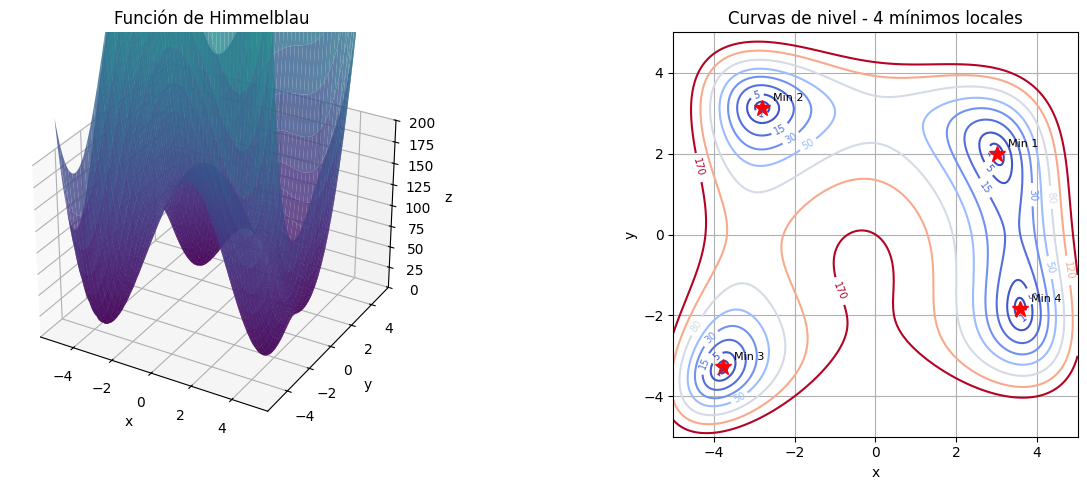

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Función de Himmelblau
def f(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Gradiente analítico
def grad_f(x, y):
    df_dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    df_dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([df_dx, df_dy])

# Visualizar la función
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_zlim(0, 200)
ax1.set_title('Función de Himmelblau')

# Curvas de nivel + marcar los 4 mínimos
ax2 = fig.add_subplot(122)
contours = ax2.contour(X, Y, Z, levels=[1, 5, 15, 30, 50, 80, 120, 170], cmap='coolwarm')
ax2.clabel(contours, inline=True, fontsize=7)
minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]
for i, (mx, my) in enumerate(minimos):
    ax2.plot(mx, my, 'r*', markersize=12)
    ax2.annotate(f'Min {i+1}', (mx, my), textcoords='offset points', xytext=(8, 5), fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel - 4 mínimos locales')
ax2.grid(True)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

### a) Gradiente descendente con paso fijo

Inicio (-2, 4.5) → Mínimo (-2.8051, 3.1313), f = 0.000000, Iters: 34
Inicio (1, 4) → Mínimo (3.0000, 2.0000), f = 0.000000, Iters: 92
Inicio (-4, -1) → Mínimo (-3.7793, -3.2832), f = 0.000000, Iters: 37
Inicio (4, -3) → Mínimo (3.5844, -1.8481), f = 0.000000, Iters: 73


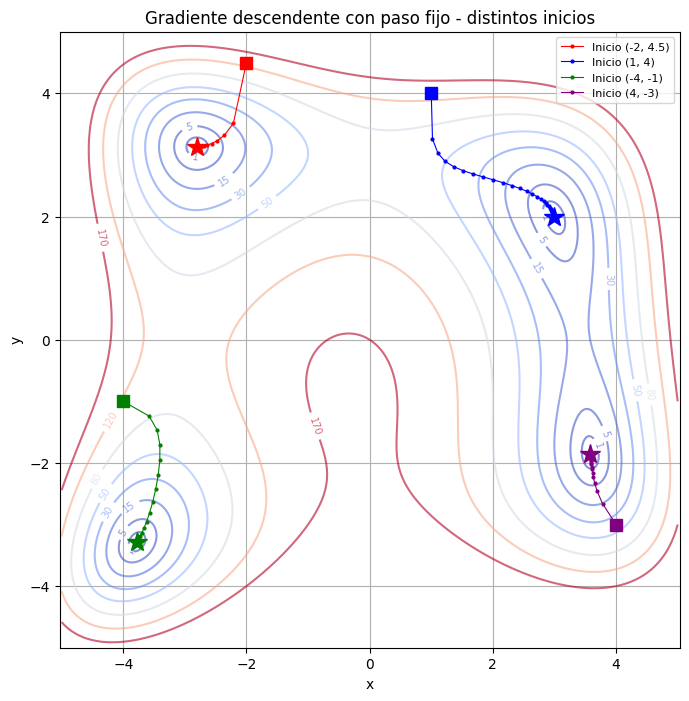

In [20]:
# Gradiente descendente con paso fijo - probar distintos puntos iniciales
puntos_iniciales = [(-2, 4.5), (1, 4), (-4, -1), (4, -3)]
alpha = 0.005  # Paso fijo (pequeño para evitar divergencia)
tol = 1e-6
max_iters = 5000

resultados_fijo = []

for x0, y0 in puntos_iniciales:
    x_hist = [x0]
    y_hist = [y0]
    xk, yk = x0, y0
    
    for i in range(max_iters):
        grad = grad_f(xk, yk)
        xk_new = xk - alpha * grad[0]
        yk_new = yk - alpha * grad[1]
        
        if np.linalg.norm([xk_new - xk, yk_new - yk]) < tol:
            break
        
        xk, yk = xk_new, yk_new
        x_hist.append(xk)
        y_hist.append(yk)
    
    resultados_fijo.append((x_hist, y_hist))
    print(f"Inicio ({x0}, {y0}) → Mínimo ({xk:.4f}, {yk:.4f}), f = {f(xk, yk):.6f}, Iters: {len(x_hist)-1}")

# Visualizar trayectorias
colores = ['red', 'blue', 'green', 'purple']
plt.figure(figsize=(8, 8))
contours = plt.contour(X, Y, Z, levels=[1, 5, 15, 30, 50, 80, 120, 170], cmap='coolwarm', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=7)

for idx, ((x_hist, y_hist), (x0, y0)) in enumerate(zip(resultados_fijo, puntos_iniciales)):
    plt.plot(x_hist, y_hist, 'o-', color=colores[idx], markersize=2, linewidth=0.8, 
             label=f'Inicio ({x0}, {y0})')
    plt.plot(x_hist[0], y_hist[0], 's', color=colores[idx], markersize=8)
    plt.plot(x_hist[-1], y_hist[-1], '*', color=colores[idx], markersize=15)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradiente descendente con paso fijo - distintos inicios')
plt.legend(fontsize=8)
plt.grid(True)
plt.axis('equal')
plt.show()

### b) Gradiente descendente con dirección normalizada

Inicio (-2, 4.5) → Mínimo (-2.8079, 3.0980), f = 0.044427, Iters: 5000
Inicio (1, 4) → Mínimo (2.9882, 1.9953), f = 0.006589, Iters: 5000
Inicio (-4, -1) → Mínimo (-3.7502, -3.3013), f = 0.078358, Iters: 5000
Inicio (4, -3) → Mínimo (3.6245, -1.8445), f = 0.086168, Iters: 5000


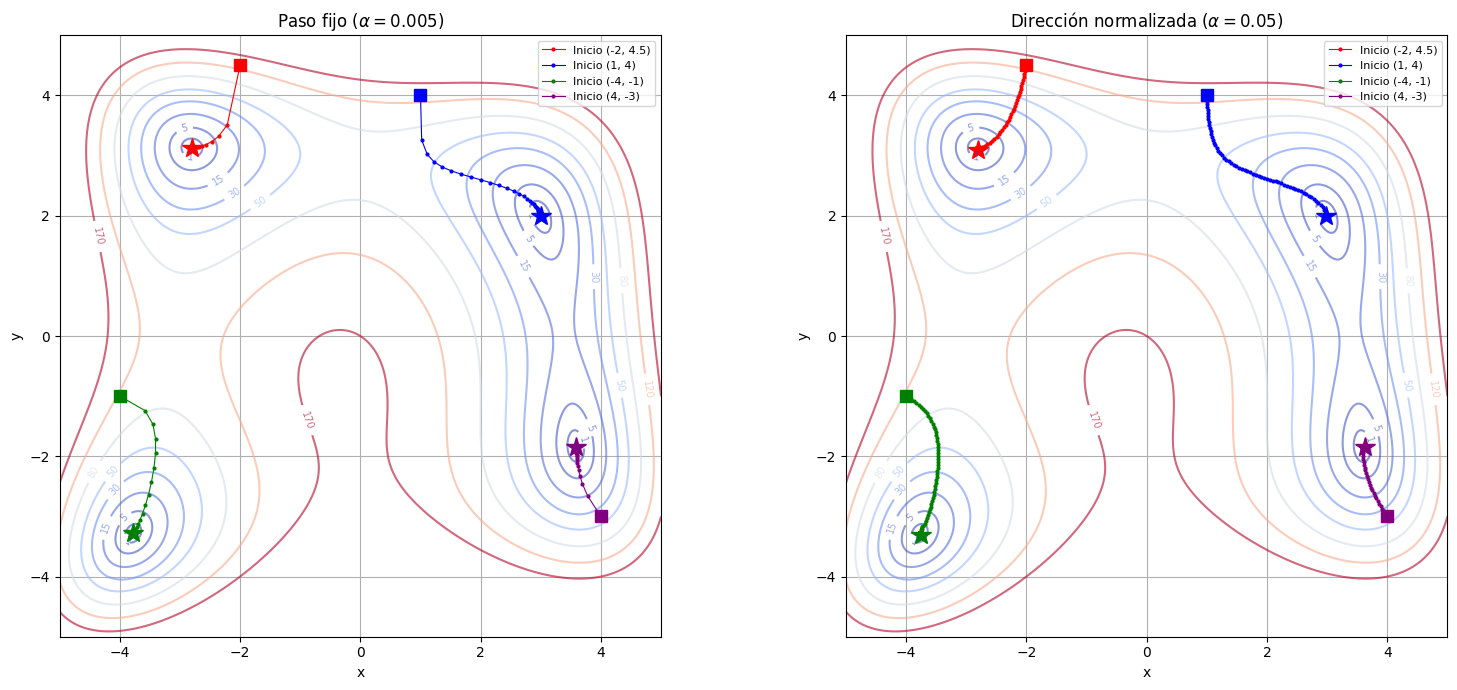

In [ ]:
# Gradiente descendente con dirección normalizada - mismos puntos iniciales
alpha = 0.05  # Paso más grande (se normaliza la dirección)
tol = 1e-6
max_iters = 5000

resultados_norm = []

for x0, y0 in puntos_iniciales:
    x_hist = [x0]
    y_hist = [y0]
    xk, yk = x0, y0
    
    for i in range(max_iters):
        grad = grad_f(xk, yk)
        norma = np.linalg.norm(grad)
        
        if norma < tol:
            break
        
        grad_normalizado = grad / norma
        xk_new = xk - alpha * grad_normalizado[0]
        yk_new = yk - alpha * grad_normalizado[1]
        
        xk, yk = xk_new, yk_new
        x_hist.append(xk)
        y_hist.append(yk)
    
    resultados_norm.append((x_hist, y_hist))
    print(f"Inicio ({x0}, {y0}) → Mínimo ({xk:.4f}, {yk:.4f}), f = {f(xk, yk):.6f}, Iters: {len(x_hist)-1}")

# Comparar paso fijo vs normalizado para un mismo punto inicial
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, resultados, titulo in zip(axes, [resultados_fijo, resultados_norm], 
                                     ['Paso fijo ($\\alpha = 0.005$)', 'Dirección normalizada ($\\alpha = 0.05$)']):
    contours = ax.contour(X, Y, Z, levels=[1, 5, 15, 30, 50, 80, 120, 170], cmap='coolwarm', alpha=0.6)
    ax.clabel(contours, inline=True, fontsize=7)
    
    for idx, ((x_hist, y_hist), (x0, y0)) in enumerate(zip(resultados, puntos_iniciales)):
        ax.plot(x_hist, y_hist, 'o-', color=colores[idx], markersize=2, linewidth=0.8,
                label=f'Inicio ({x0}, {y0})')
        ax.plot(x_hist[0], y_hist[0], 's', color=colores[idx], markersize=8)
        ax.plot(x_hist[-1], y_hist[-1], '*', color=colores[idx], markersize=15)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(titulo)
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()